# Logistic Regression from Scratch

This notebook implements logistic regression from scratch for the Dry Bean Dataset, including:
1. Loading and visualizing the data
2. Sigmoid function
3. Cost function
4. Gradient
5. Learning parameters using gradient descent
6. Plotting the decision boundary
7. Evaluating logistic regression
8. Regularized logistic regression (all of the above)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Softmax Regression: Single unified model for all classes
from sklearn.preprocessing import OneHotEncoder

In [2]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if 'logistic_regression' in sys.modules:
        print("Module 'logistic_regression' found in cache. Forcing reload...")
        importlib.reload(sys.modules['logistic_regression'])
    elif 'utils' in sys.modules:
        print("Module 'utils' found in cache. Forcing reload...")
        importlib.reload(sys.modules['utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    from logistic_regression import LogisticRegression_lr
    import utils as ut
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your 'logistic_regression' folder and 'logistic_regression.py' are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

In [3]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)

## 1. Loading and Visualizing the Data


In [4]:
# Load the dataset
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nDataset info:")
print(df.info())

Dataset shape: (13611, 17)

First few rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFac

In [5]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# For binary classification, let's select two classes for visualization
# We'll use the two most common classes
class_counts = y.value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nSelected classes for binary classification: {class_counts.index[0]} vs {class_counts.index[1]}")

# Filter data for binary classification
selected_classes = [class_counts.index[0], class_counts.index[1]]
binary_mask = y.isin(selected_classes)
X_binary = X[binary_mask].values
y_binary = y[binary_mask].values

# Encode labels to 0 and 1
label_encoder = LabelEncoder()
y_binary_encoded = label_encoder.fit_transform(y_binary)

# desired order
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']


print(f"\nBinary dataset shape: {X_binary.shape}")
print(f"Class distribution in binary dataset:")
print(pd.Series(y_binary_encoded).value_counts().sort_index())


Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Selected classes for binary classification: DERMASON vs SIRA

Binary dataset shape: (6182, 16)
Class distribution in binary dataset:
0    3546
1    2636
Name: count, dtype: int64


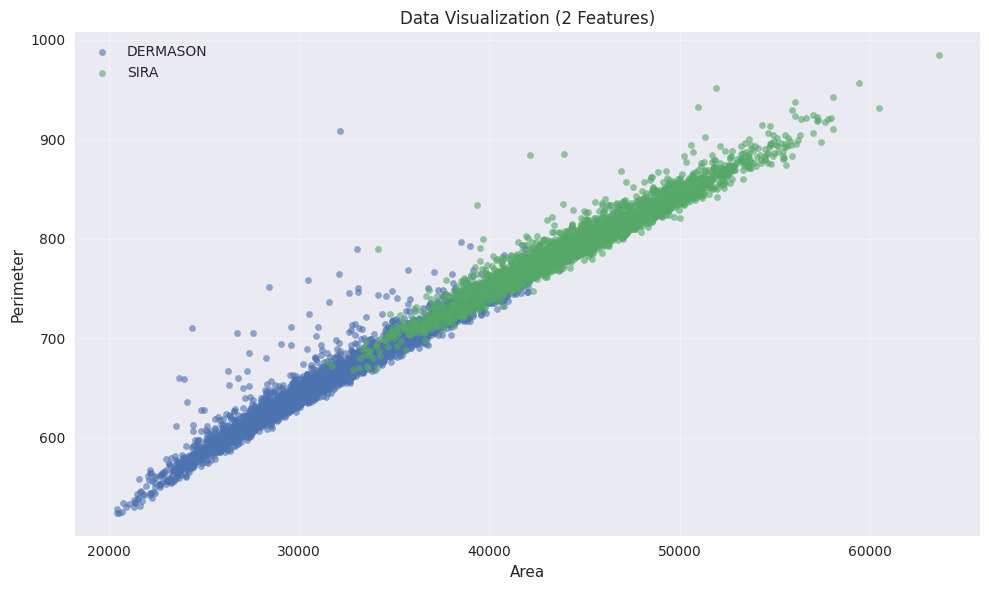

In [6]:
# Visualize the data - select 2 features for visualization
feature1_idx = 0  # Area
feature2_idx = 1  # Perimeter

X_vis = X_binary[:, [feature1_idx, feature2_idx]]
feature_names = X.columns.tolist()

plt.figure(figsize=(10, 6))
for class_label in np.unique(y_binary_encoded):
    mask = y_binary_encoded == class_label
    plt.scatter(X_vis[mask, 0], X_vis[mask, 1], 
                label=f'{label_encoder.inverse_transform([class_label])[0]}', 
                alpha=0.6, s=20)
plt.xlabel(feature_names[feature1_idx])
plt.ylabel(feature_names[feature2_idx])
plt.title('Data Visualization (2 Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Prepare data for training (using 2 features for decision boundary visualization)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_binary, y_binary_encoded, test_size=0.2, random_state=42, stratify=y_binary_encoded
)

# For decision boundary plotting, use 2 features
X_train_2d = X_train_full[:, [feature1_idx, feature2_idx]]
X_test_2d = X_test_full[:, [feature1_idx, feature2_idx]]

# Standardize features
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Add intercept term (column of ones)
X_train_2d_scaled = np.hstack([np.ones((X_train_2d_scaled.shape[0], 1)), X_train_2d_scaled])
X_test_2d_scaled = np.hstack([np.ones((X_test_2d_scaled.shape[0], 1)), X_test_2d_scaled])

print(f"Training set shape: {X_train_2d_scaled.shape}")
print(f"Test set shape: {X_test_2d_scaled.shape}")


Training set shape: (4945, 3)
Test set shape: (1237, 3)


## 2. Sigmoid Function


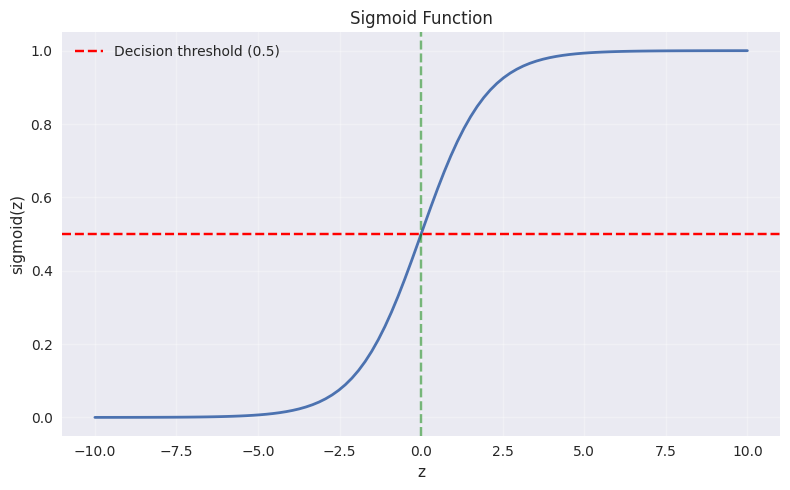

In [8]:
# Create logistic regression class
lg = LogisticRegression_lr()

# Visualize sigmoid function
z = np.linspace(-10, 10, 100)
sigmoid_values = lg.sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid_values, linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision threshold (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Cost Function


In [9]:
# Test the cost function with initial parameters
initial_w = np.zeros(X_train_2d_scaled.shape[1])
initial_b = 0.
initial_cost = lg.compute_cost(X_train_2d_scaled, y_train_full, initial_w, initial_b)
print(f"Initial cost with zero parameters: {initial_cost:.4f}")

Initial cost with zero parameters: 0.6931


## 4. Gradient and Learning Parameters using Gradient Descent


In [10]:
# Test the gradient function
alpha = 0.01
num_iters = 10000
dj_dw, dj_db, w, b, J_history, _ = lg.gradient_descent(X_train_2d_scaled, y_train_full, initial_w, initial_b,
                        alpha, num_iters, 0)
print(f"Initial gradient shape: {dj_db[0].shape} {dj_dw[0].shape}")
print(f"Initial gradient values: {dj_db[0]} {dj_dw[0]}")

print(f"\nFinal parameters (w)(b): {w} {b}")

Iteration    0: Cost   0.6899   
Iteration 1000: Cost   0.2401   
Iteration 2000: Cost   0.2114   
Iteration 3000: Cost   0.2015   
Iteration 4000: Cost   0.1967   
Iteration 5000: Cost   0.1941   
Iteration 6000: Cost   0.1925   
Iteration 7000: Cost   0.1914   
Iteration 8000: Cost   0.1907   
Iteration 9000: Cost   0.1903   
Iteration 9999: Cost   0.1900   
Initial gradient shape: () (3,)
Initial gradient values: 0.07350859453993933 [ 0.07350859 -0.39854669 -0.3981801 ]

Final parameters (w)(b): [-0.51498457  2.33087128  2.4219178 ] -0.5149845654038275


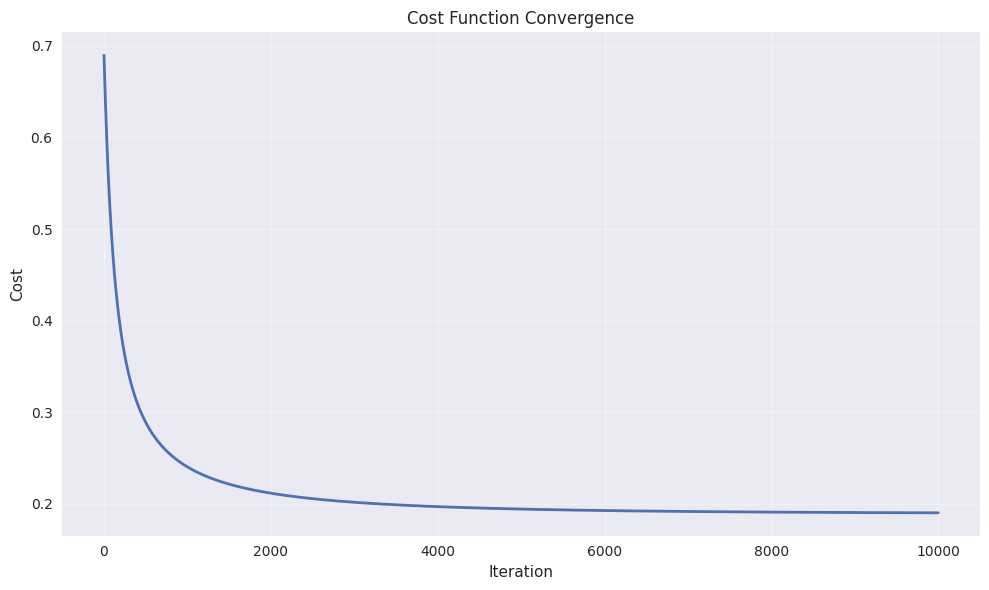

In [11]:
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(J_history, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Plotting the Decision Boundary


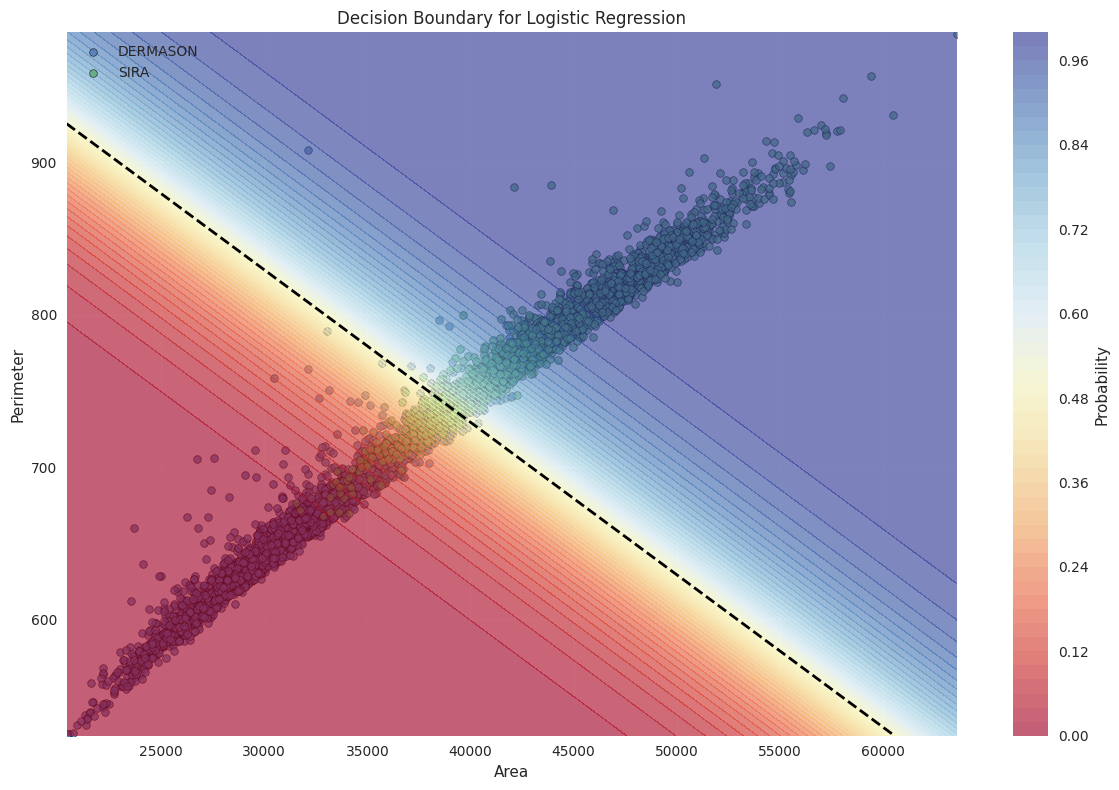

In [12]:
# Extract feature weights (w might include intercept if X has intercept column)
# If w has 3 elements and X_train_2d_scaled has intercept, use w[1:] as feature weights
if len(w) == 3:  # w includes intercept term
    w_features = w[1:]  # Extract feature weights (skip intercept)
    b_total = w[0] + b  # Combine intercept from w and bias b
else:
    w_features = w  # w is already just feature weights
    b_total = b  # Use b as bias

# Plot decision boundary
lg.plot_decision_boundary(
    X_train_2d, y_train_full, w_features, b_total, scaler_2d, 
    [feature_names[feature1_idx], feature_names[feature2_idx]], 
    label_encoder
)

## 6. Evaluating Logistic Regression


In [13]:
y_train_pred, train_accuracy, train_cost = lg.evaluate(X_train_2d_scaled, y_train_full, w, b)
y_test_pred, test_accuracy, test_cost = lg.evaluate(X_test_2d_scaled, y_test_full, w, b)

print("Training Results:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  Cost: {train_cost:.4f}")
print("\nTest Results:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Cost: {test_cost:.4f}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_full, y_test_pred, 
                          target_names=[label_encoder.inverse_transform([0])[0], 
                                       label_encoder.inverse_transform([1])[0]]))

Training Results:
  Accuracy: 0.9132
  Cost: 0.1900

Test Results:
  Accuracy: 0.9038
  Cost: 0.1970

Classification Report (Test Set):
              precision    recall  f1-score   support

    DERMASON       0.93      0.90      0.92       710
        SIRA       0.87      0.91      0.89       527

    accuracy                           0.90      1237
   macro avg       0.90      0.90      0.90      1237
weighted avg       0.90      0.90      0.90      1237



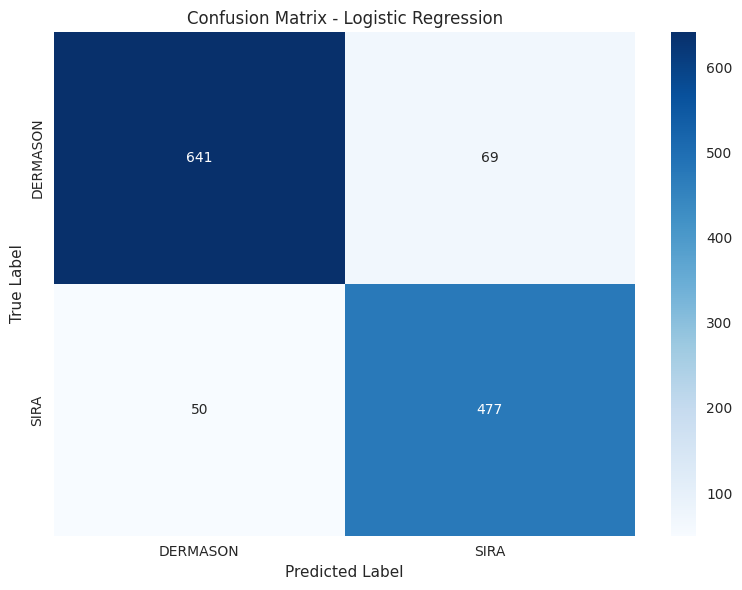

In [14]:
# Confusion matrix
cm = lg.confusion_matrix(y_test_full, y_test_pred, label_encoder)

# Regularized Logistic Regression

Now we'll implement regularized logistic regression with L2 regularization (Ridge).


## 1. Loading and Visualizing the Data (Regularized)

We'll use the same data as before.


In [15]:
# Use the same data prepared earlier
print("Using the same binary classification dataset")
print(f"Training set shape: {X_train_2d_scaled.shape}")
print(f"Test set shape: {X_test_2d_scaled.shape}")


Using the same binary classification dataset
Training set shape: (4945, 3)
Test set shape: (1237, 3)


## 2. Sigmoid Function (Regularized)

Same sigmoid function as before.


## 3. Cost Function (Regularized)


In [16]:
# Test the regularized cost function
lambda_reg = 1.0
initial_cost_reg = lg.compute_cost_regularized(X_train_2d_scaled, y_train_full, initial_w, initial_b, lambda_reg)
print(f"Initial regularized cost with zero parameters (lambda={lambda_reg}): {initial_cost_reg:.4f}")

Initial regularized cost with zero parameters (lambda=1.0): 0.6931


## 4. Gradient (Regularized) and Learning Parameters using Gradient Descent (Regularized)


In [17]:
# Train the regularized model with different lambda values
lambda_values = [0.01, 0.1, 1.0, 10.0]
results_reg = {}

for lambda_reg in lambda_values:
    print(f"\n{'='*50}")
    print(f"Training with lambda = {lambda_reg}")
    print(f"{'='*50}")
    
    initial_w_reg = np.zeros(X_train_2d_scaled.shape[1])
    dj_dw, dj_db, w_reg, b_reg, J_history, _ = lg.gradient_descent(
        X_train_2d_scaled, y_train_full, initial_w_reg, initial_b,
        alpha, num_iters, lambda_reg, regularized=True
    )
    
    results_reg[lambda_reg] = {
        'w': w_reg,
        'b': b_reg,
        'cost_history': J_history
    }
    
    print(f"Final cost (lambda={lambda_reg}): {J_history[-1]:.4f}")
    print(f"Initial regularized gradient shape: {dj_db[0].shape} {dj_dw[0].shape}")
    print(f"Initial regularized gradient values: {dj_db[0].tolist()} {dj_dw[0].tolist()}")
    print(f"\nFinal parameters (w)(b): {w_reg} {b_reg}")



Training with lambda = 0.01
Iteration    0: Cost   0.6899   
Iteration 1000: Cost   0.2401   
Iteration 2000: Cost   0.2114   
Iteration 3000: Cost   0.2015   
Iteration 4000: Cost   0.1967   
Iteration 5000: Cost   0.1941   
Iteration 6000: Cost   0.1925   
Iteration 7000: Cost   0.1914   
Iteration 8000: Cost   0.1908   
Iteration 9000: Cost   0.1903   
Iteration 9999: Cost   0.1900   
Final cost (lambda=0.01): 0.1900
Initial regularized gradient shape: () (3,)
Initial regularized gradient values: 0.07350859453993933 [0.07350859453993933, -0.39854669303583545, -0.39818009645589875]

Final parameters (w)(b): [-0.514905    2.33069899  2.42173635] -0.5149868142821261

Training with lambda = 0.1
Iteration    0: Cost   0.6899   
Iteration 1000: Cost   0.2402   
Iteration 2000: Cost   0.2115   
Iteration 3000: Cost   0.2016   
Iteration 4000: Cost   0.1968   
Iteration 5000: Cost   0.1942   
Iteration 6000: Cost   0.1926   
Iteration 7000: Cost   0.1915   
Iteration 8000: Cost   0.1909   

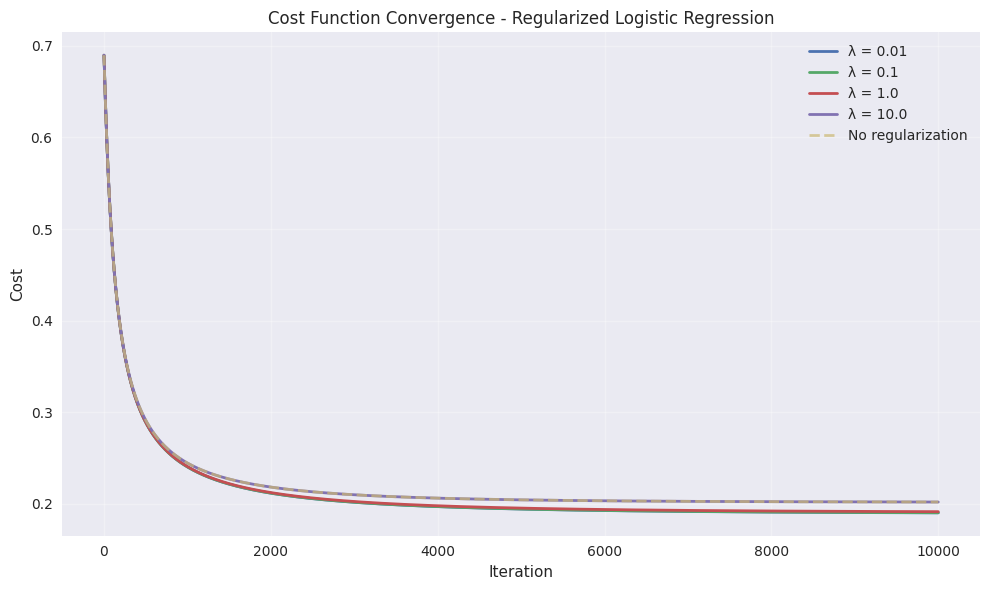

In [18]:
# Plot cost history for different lambda values
plt.figure(figsize=(10, 6))
for lambda_reg, result in results_reg.items():
    plt.plot(result['cost_history'], label=f'λ = {lambda_reg}', linewidth=2)

plt.plot(J_history, label='No regularization', linewidth=2, linestyle='--', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence - Regularized Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Plotting the Decision Boundary (Regularized)


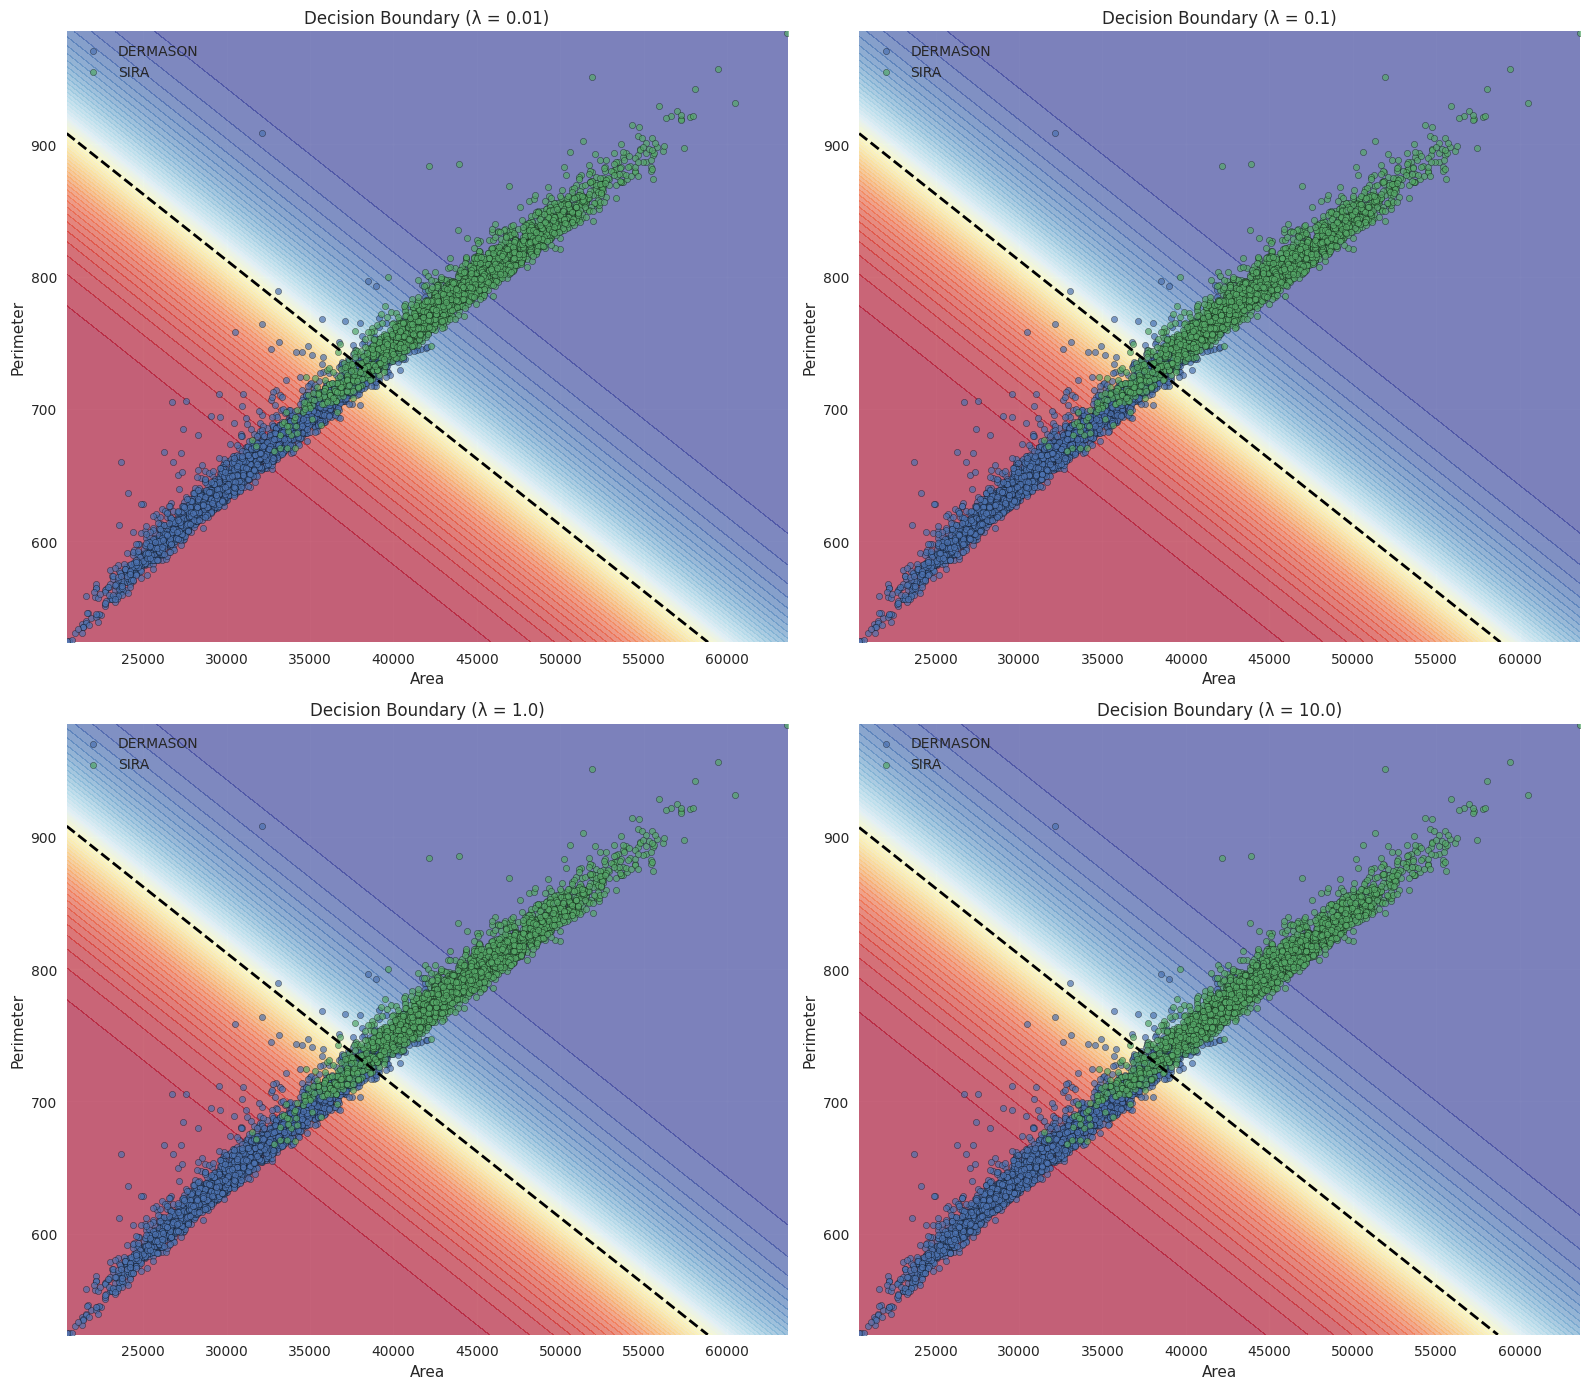

In [19]:
# Plot decision boundaries for different lambda values
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (lambda_reg, result) in enumerate(results_reg.items()):
    ax = axes[idx]
    w_reg = result['w']
    
    # Create a mesh grid
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Predict on mesh grid
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_scaled = scaler_2d.transform(mesh_points)
    mesh_points_scaled = np.hstack([np.ones((mesh_points_scaled.shape[0], 1)), mesh_points_scaled])
    Z = lg.sigmoid(mesh_points_scaled @ w_reg)
    Z = Z.reshape(xx.shape)
    
    # Plot
    contour = ax.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
    
    # Plot data points
    for class_label in np.unique(y_train_full):
        mask = y_train_full == class_label
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], 
                  label=f'{label_encoder.inverse_transform([class_label])[0]}',
                  alpha=0.7, s=20, edgecolors='black', linewidth=0.3)
    
    # Plot decision boundary
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel(feature_names[feature1_idx])
    ax.set_ylabel(feature_names[feature2_idx])
    ax.set_title(f'Decision Boundary (λ = {lambda_reg})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Evaluating Regularized Logistic Regression


In [20]:
# Evaluate models with different lambda values
print("Evaluation Results for Regularized Logistic Regression:\n")
print(f"{'Lambda':<10} {'Train Acc':<12} {'Test Acc':<12} {'Train Cost':<12} {'Test Cost':<12}")
print("-" * 60)

for lambda_reg, result in results_reg.items():
    w_reg = result['w']
    b_reg = result['b']
    
    # Predictions
    y_train_pred_reg, train_acc_reg, train_cost_reg = lg.evaluate(X_train_2d_scaled, y_train_full, w_reg, b_reg)
    y_test_pred_reg, test_acc_reg, test_cost_reg = lg.evaluate(X_test_2d_scaled, y_test_full, w_reg, b_reg)
    
    print(f"{lambda_reg:<10.2f} {train_acc_reg:<12.4f} {test_acc_reg:<12.4f} {train_cost_reg:<12.4f} {test_cost_reg:<12.4f}")

# Compare with non-regularized
print("\n" + "-" * 60)
print("Non-regularized model:")
print(f"{'N/A':<10} {train_accuracy:<12.4f} {test_accuracy:<12.4f} {train_cost_reg:<12.4f} {test_cost_reg:<12.4f}")


Evaluation Results for Regularized Logistic Regression:

Lambda     Train Acc    Test Acc     Train Cost   Test Cost   
------------------------------------------------------------
0.01       0.9132       0.9038       0.1900       0.1970      
0.10       0.9132       0.9038       0.1900       0.1970      
1.00       0.9132       0.9038       0.1901       0.1972      
10.00      0.9134       0.9038       0.1917       0.1990      

------------------------------------------------------------
Non-regularized model:
N/A        0.9132       0.9038       0.1917       0.1990      


In [21]:
# Select best lambda based on test accuracy
best_lambda = max(results_reg.keys(), key=lambda l: accuracy_score(
    y_test_full, 
    lg.predict(X_test_2d_scaled, results_reg[l]['w'], results_reg[l]['b'])
))

w_best = results_reg[best_lambda]['w']
b_best = results_reg[best_lambda]['b']
y_test_pred_best = lg.predict(X_test_2d_scaled, w_best, b_best)

print(f"\nBest lambda value: {best_lambda}")
print(f"Test accuracy with best lambda: {accuracy_score(y_test_full, y_test_pred_best):.4f}")

# Classification report for best model
print("\nClassification Report (Test Set) - Best Regularized Model:")
print(classification_report(y_test_full, y_test_pred_best, 
                          target_names=[label_encoder.inverse_transform([0])[0], 
                                       label_encoder.inverse_transform([1])[0]]))



Best lambda value: 0.01
Test accuracy with best lambda: 0.9038

Classification Report (Test Set) - Best Regularized Model:
              precision    recall  f1-score   support

    DERMASON       0.93      0.90      0.92       710
        SIRA       0.87      0.91      0.89       527

    accuracy                           0.90      1237
   macro avg       0.90      0.90      0.90      1237
weighted avg       0.90      0.90      0.90      1237



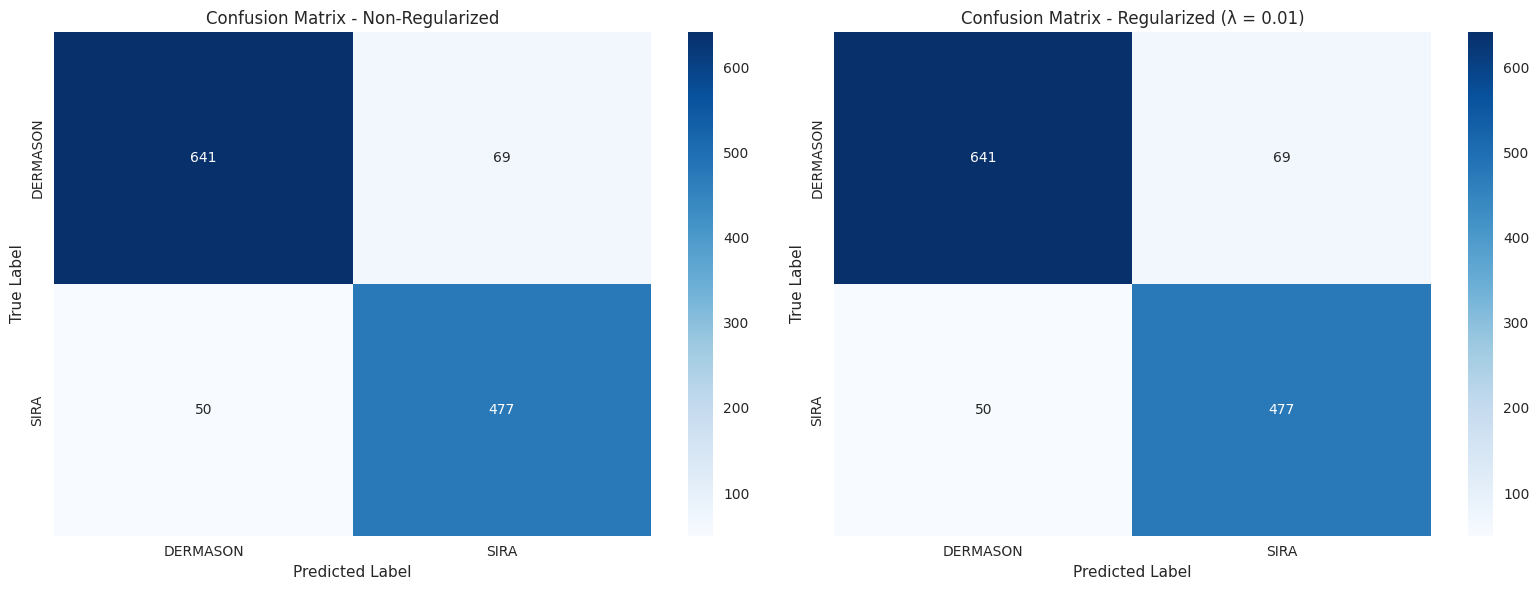

In [22]:
# Confusion matrix for best regularized model
cm_reg = confusion_matrix(y_test_full, y_test_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-regularized
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]],
            yticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Confusion Matrix - Non-Regularized')

# Regularized
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]],
            yticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]])
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_title(f'Confusion Matrix - Regularized (λ = {best_lambda})')

plt.tight_layout()
plt.show()


## Summary

This notebook implemented logistic regression from scratch, including:

1. **Data Loading and Visualization**: Loaded the Dry Bean Dataset and prepared it for binary classification
2. **Sigmoid Function**: Implemented the sigmoid activation function
3. **Cost Function**: Implemented the binary cross-entropy cost function
4. **Gradient**: Computed the gradient of the cost function
5. **Gradient Descent**: Learned parameters using iterative gradient descent
6. **Decision Boundary**: Visualized the decision boundary in 2D feature space
7. **Evaluation**: Assessed model performance using accuracy, classification report, and confusion matrix
8. **Regularized Logistic Regression**: Implemented all of the above with L2 regularization to prevent overfitting

The regularized version helps control model complexity and can improve generalization performance.


# Full data set Regularized Logistic Regression

Train model with the entire data. In this case the data visualization will be omited as it adds complexity

## 1. Loading and Visualizing the Data (Regularized Full)

In [23]:
# Separate features and target (using all data)
X_full = df.drop(columns=['Class']).values # Use all 16 features
y_full = df['Class'].values # Use all 7 classes

# Encode the 7 class labels to integers (0 to 6) for compatibility
label_encoder_full = LabelEncoder()
y_encoded_full = label_encoder_full.fit_transform(y_full)
num_classes = len(label_encoder_full.classes_)
feature_names = df.drop(columns=['Class']).columns.tolist()
target_names = label_encoder.classes_

print(f"Full dataset shape: {X_full.shape}")
print(f"Number of classes: {num_classes}")

# Split the full dataset
X_train_full, X_, y_train_full, y_ = train_test_split(
    X_full, y_encoded_full, test_size=0.33, random_state=42, stratify=y_encoded_full
)

X_cv_full, X_test_full, y_cv_full, y_test_full = train_test_split(
    X_, y_, test_size=0.5, random_state=42, stratify=y_
)

# Scale all 16 features
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full)
X_test_scaled = scaler_full.transform(X_test_full)
X_cv_scaled = scaler_full.transform(X_cv_full)

# Initial parameters for a full model (16 features + bias)
initial_w = np.zeros(X_train_scaled.shape[1])
initial_b = 0.

Full dataset shape: (13611, 16)
Number of classes: 7


In [24]:
# Regularization tuning: Convert C values to lambda (lambda = 1/C)
# Scikit_Learn uses: C_values = np.logspace(-3, 6, 7) = [0.001, 0.032, 1.0, 31.6, 1000, 31623, 1000000]
# Best C = 1000, so best lambda = 1/1000 = 0.001
# We'll test a range of lambda values corresponding to C values
C_values = np.logspace(-3, 6, 7)  # Same as Scikit_Learn: from 0.001 to 1000000
lambda_values = 1.0 / C_values  # Convert C to lambda (lambda = 1/C)

print("Regularization Tuning for One-vs-All:")
print(f"  C values (Scikit_Learn): {C_values}")
print(f"  Lambda values (Lab): {lambda_values}")
print(f"  Number of iterations: {num_iters}")
print(f"  Learning rate: {alpha}")

Regularization Tuning for One-vs-All:
  C values (Scikit_Learn): [1.00000000e-03 3.16227766e-02 1.00000000e+00 3.16227766e+01
 1.00000000e+03 3.16227766e+04 1.00000000e+06]
  Lambda values (Lab): [1.00000000e+03 3.16227766e+01 1.00000000e+00 3.16227766e-02
 1.00000000e-03 3.16227766e-05 1.00000000e-06]
  Number of iterations: 10000
  Learning rate: 0.01


## 2. Gradient (Regularized) and Learning Parameters using Gradient Descent (Regularized Full)


In [25]:
"""
Trains K binary logistic regression models using the One-vs-All strategy with regularization tuning.

This function tests multiple lambda values and selects the best one based on CV accuracy,
matching the approach in Scikit_Learn notebook.
"""
print("=" * 70)
print("One-vs-All Training with Regularization Tuning")
print("=" * 70)
print(f"Testing {len(lambda_values)} lambda values: {lambda_values}")
print(f"Number of iterations: {num_iters}")
print(f"Learning rate: {alpha}\n")

# Store results for each lambda value
lambda_results = {}
results_full_reg = {}

# Test each lambda value
for lambda_reg in lambda_values:
    print(f"\n{'='*70}")
    print(f"Testing lambda = {lambda_reg:.6f} (C = {1/lambda_reg:.3f})")
    print(f"{'='*70}")
    
    all_w_lambda = []
    all_b_lambda = []
    all_J_history = []
    
    # Train K binary models for this lambda
    for i in range(num_classes):
        # 1. Create the binary target y_i: 1 for class i, 0 for all others
        y_ova = (y_train_full == i).astype(int)
        
        print(f"\nTraining model for class {label_encoder_full.inverse_transform([i])[0]} (Class {i} vs All)")
        
        # 2. Train the model using the existing gradient descent
        initial_w_i = np.zeros(X_train_scaled.shape[1])
        dj_dw, dj_db, w_i, b_i, J_history, _ = lg.gradient_descent(
            X_train_scaled, y_ova, initial_w_i, initial_b,
            alpha, num_iters, lambda_reg, regularized=True
        )
        
        # 3. Store the learned parameters
        all_w_lambda.append(w_i)
        all_b_lambda.append(b_i)
        all_J_history.append(J_history)
        print(f"Final cost: {J_history[-1]:.4f}")
    
    # Evaluate on CV set for this lambda
    y_cv_pred_lambda, _ = lg.predict_multiclass_ova(
        X_cv_scaled, np.array(all_w_lambda), np.array(all_b_lambda), num_classes
    )
    cv_accuracy_lambda = accuracy_score(y_cv_full, y_cv_pred_lambda)
    
    # Store results
    lambda_results[lambda_reg] = {
        'all_w': all_w_lambda,
        'all_b': all_b_lambda,
        'cv_accuracy': cv_accuracy_lambda
    }

    results_full_reg[lambda_reg] = {
        'all_w': all_w_lambda,
        'all_b': all_b_lambda,
        'cost_history': all_J_history
    }
    
    print(f"\nCV Accuracy for lambda={lambda_reg:.6f}: {cv_accuracy_lambda:.4f}")

# Select best lambda based on CV accuracy
best_lambda = max(lambda_results.keys(), key=lambda l: lambda_results[l]['cv_accuracy'])
best_cv_accuracy = lambda_results[best_lambda]['cv_accuracy']

print(f"\n{'='*70}")
print(f"Best lambda: {best_lambda:.6f} (C = {1/best_lambda:.3f})")
print(f"Best CV Accuracy: {best_cv_accuracy:.4f}")
print(f"{'='*70}\n")

# Use best lambda for final model
all_w = lambda_results[best_lambda]['all_w']
all_b = lambda_results[best_lambda]['all_b']
lambda_reg = best_lambda  # Update lambda_reg to best value

print(f"Using best lambda ({best_lambda:.6f}) for final One-vs-All model")

One-vs-All Training with Regularization Tuning
Testing 7 lambda values: [1.00000000e+03 3.16227766e+01 1.00000000e+00 3.16227766e-02
 1.00000000e-03 3.16227766e-05 1.00000000e-06]
Number of iterations: 10000
Learning rate: 0.01


Testing lambda = 1000.000000 (C = 0.001)

Training model for class BARBUNYA (Class 0 vs All)
Iteration    0: Cost   0.6909   
Iteration 1000: Cost   0.2651   
Iteration 2000: Cost   0.2412   
Iteration 3000: Cost   0.2370   
Iteration 4000: Cost   0.2360   
Iteration 5000: Cost   0.2357   
Iteration 6000: Cost   0.2356   
Iteration 7000: Cost   0.2356   
Iteration 8000: Cost   0.2356   
Iteration 9000: Cost   0.2356   
Iteration 9999: Cost   0.2356   
Final cost: 0.2356

Training model for class BOMBAY (Class 1 vs All)
Iteration    0: Cost   0.6896   
Iteration 1000: Cost   0.1323   
Iteration 2000: Cost   0.0838   
Iteration 3000: Cost   0.0676   
Iteration 4000: Cost   0.0598   
Iteration 5000: Cost   0.0553   
Iteration 6000: Cost   0.0526   
Iteration 7000

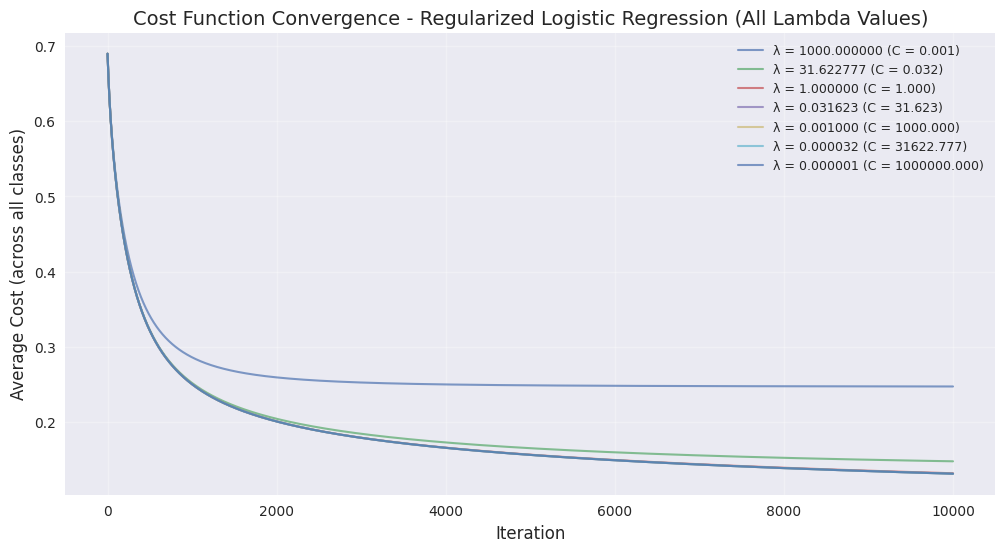

In [26]:
# Plot cost history for all lambda values
# For each lambda, we'll plot the average cost across all classes
plt.figure(figsize=(12, 6))

for lambda_reg, result in results_full_reg.items():
    # result['cost_history'] is a list of lists (one J_history per class)
    # Calculate average cost across all classes for each iteration
    all_cost_histories = result['cost_history']
    
    # Find the maximum length to handle different iteration counts
    max_len = max(len(hist) for hist in all_cost_histories)
    
    # Average cost across all classes for each iteration
    avg_cost_history = []
    for iter_idx in range(max_len):
        costs_at_iter = [hist[iter_idx] if iter_idx < len(hist) else hist[-1] 
                         for hist in all_cost_histories]
        avg_cost_history.append(np.mean(costs_at_iter))
    
    # Convert lambda to C for label
    C_val = 1 / lambda_reg
    label = f'λ = {lambda_reg:.6f} (C = {C_val:.3f})'
    
    plt.plot(avg_cost_history, label=label, linewidth=1.5, alpha=0.7)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Average Cost (across all classes)', fontsize=12)
plt.title('Cost Function Convergence - Regularized Logistic Regression (All Lambda Values)', fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.show()

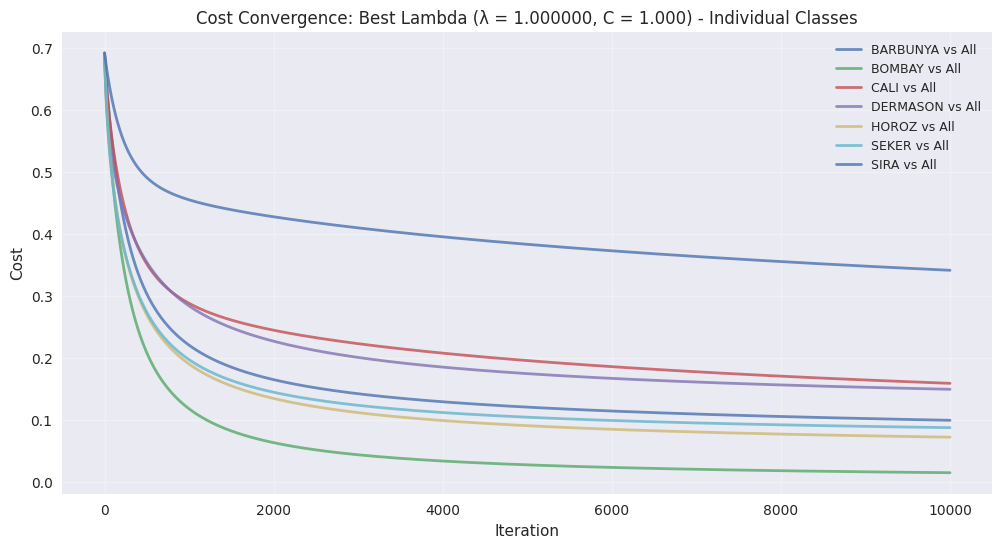

In [27]:
plt.figure(figsize=(12, 6))
# Also create a subplot version showing individual class costs for best lambda
if best_lambda in results_full_reg:
    # Bottom plot: Best lambda (individual classes)
    best_result = results_full_reg[best_lambda]
    for i, cost_history in enumerate(best_result['cost_history']):
        class_name = label_encoder_full.inverse_transform([i])[0]
        plt.plot(cost_history, label=f'{class_name} vs All', linewidth=2, alpha=0.8)
    
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Cost', fontsize=11)
plt.title(f'Cost Convergence: Best Lambda (λ = {best_lambda:.6f}, C = {1/best_lambda:.3f}) - Individual Classes', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()


Regularization Tuning Summary:
Lambda          C               CV Accuracy    
---------------------------------------------
0.000001        1000000.000     0.9016         
0.000032        31622.777       0.9016         
0.001000        1000.000        0.9016         
0.031623        31.623          0.9016         
1.000000        1.000           0.9016         
31.622777       0.032           0.9012         
1000.000000     0.001           0.8500         


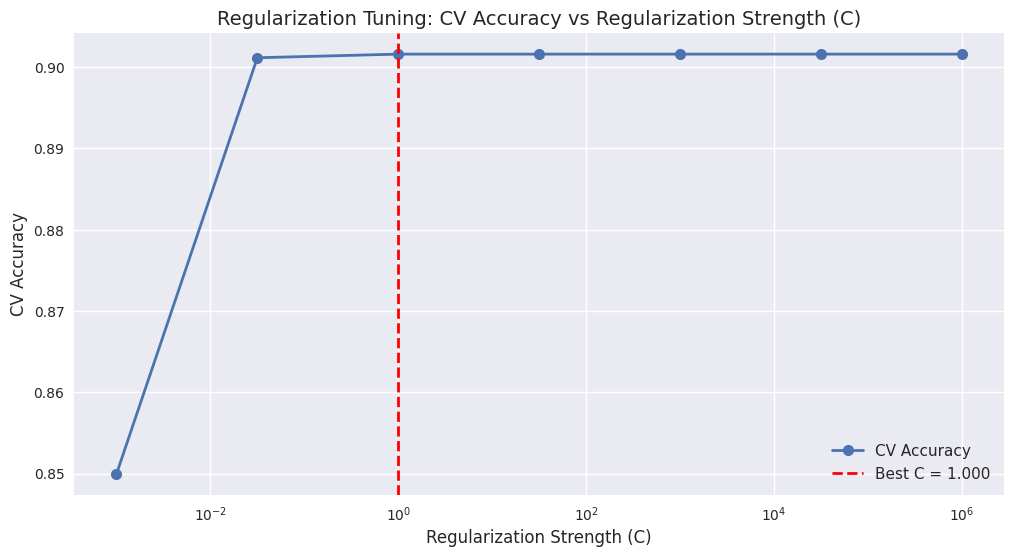

In [28]:
# Plot regularization tuning results (CV Accuracy vs Lambda)
plt.figure(figsize=(12, 6))

# Extract lambda values and CV accuracies
lambda_vals = list(lambda_results.keys())
cv_accs = [lambda_results[l]['cv_accuracy'] for l in lambda_vals]

# Convert lambda to C for x-axis (matching Scikit_Learn format)
C_vals = [1/l for l in lambda_vals]

plt.plot(C_vals, cv_accs, marker='o', linewidth=2, markersize=8, label='CV Accuracy')
plt.axvline(x=1/best_lambda, color='r', linestyle='--', linewidth=2, label=f'Best C = {1/best_lambda:.3f}')

plt.xlabel('Regularization Strength (C)', fontsize=12)
plt.ylabel('CV Accuracy', fontsize=12)
plt.title('Regularization Tuning: CV Accuracy vs Regularization Strength (C)', fontsize=14)
plt.legend(fontsize=11)
plt.xscale('log')  # Log scale to match Scikit_Learn visualization

print(f"\nRegularization Tuning Summary:")
print(f"{'Lambda':<15} {'C':<15} {'CV Accuracy':<15}")
print("-" * 45)
for l in sorted(lambda_vals):
    print(f"{l:<15.6f} {1/l:<15.3f} {lambda_results[l]['cv_accuracy']:<15.4f}")

In [29]:
# 1. Define the desired order for the display labels
new_target_names = [
    'SEKER', 
    'BARBUNYA', 
    'BOMBAY', 
    'CALI', 
    'HOROZ', 
    'SIRA', 
    'DERMASON'
]

# Make predictions on the test set
y_test_pred_ova, y_test_proba_ova = lg.predict_multiclass_ova(X_test_scaled, all_w, all_b, num_classes)
y_cv_pred_ova, y_cv_proba_ova = lg.predict_multiclass_ova(X_cv_scaled, all_w, all_b, num_classes)
y_training_pred_ova, y_training_proba_ova = lg.predict_multiclass_ova(X_train_scaled, all_w, all_b, num_classes)

# Now you have access to the probabilities array:
print(f"Shape of predictions array (indices): {y_test_pred_ova.shape}")
print(f"Shape of probabilities array (m x K): {y_test_proba_ova.shape}")

# Evaluate the model
test_accuracy = accuracy_score(y_test_full, y_test_pred_ova)
cv_accuracy = accuracy_score(y_cv_full, y_cv_pred_ova)
train_accuracy = accuracy_score(y_train_full, y_training_pred_ova)
print(f"\nMulticlass One-vs-All Test Accuracy: {test_accuracy:.4f}")
print(f"Multiclass One-vs-All CV Accuracy: {cv_accuracy:.4f}")
print(f"Multiclass One-vs-All Training Accuracy: {train_accuracy:.4f}")

# Example using the index from the first example (e.g., 1)
selected_index = y_test_pred_ova[0] 
class_name_test = new_target_names[selected_index]
print(f"The selected index {selected_index} corresponds to the class (test dataset): {class_name_test}")
selected_index = y_cv_pred_ova[0] 
class_name_cv = new_target_names[selected_index]
print(f"The selected index {selected_index} corresponds to the class (cv dataset): {class_name_cv}")
selected_index = y_training_pred_ova[0] 
class_name_train = new_target_names[selected_index]
print(f"The selected index {selected_index} corresponds to the class (training dataset): {class_name_train}")

# Classification Report
print("\nClassification Report (Test Set - Multiclass OvA):")
print(classification_report(
    y_test_full, 
    y_test_pred_ova, 
    target_names=new_target_names)
)

Shape of predictions array (indices): (2246,)
Shape of probabilities array (m x K): (2246, 7)

Multiclass One-vs-All Test Accuracy: 0.8945
Multiclass One-vs-All CV Accuracy: 0.9016
Multiclass One-vs-All Training Accuracy: 0.9033
The selected index 4 corresponds to the class (test dataset): HOROZ
The selected index 6 corresponds to the class (cv dataset): DERMASON
The selected index 4 corresponds to the class (training dataset): HOROZ

Classification Report (Test Set - Multiclass OvA):
              precision    recall  f1-score   support

       SEKER       0.95      0.83      0.89       219
    BARBUNYA       1.00      1.00      1.00        86
      BOMBAY       0.93      0.91      0.92       269
        CALI       0.88      0.91      0.89       585
       HOROZ       0.90      0.96      0.93       318
        SIRA       0.94      0.92      0.93       334
    DERMASON       0.81      0.81      0.81       435

    accuracy                           0.89      2246
   macro avg       0.9


Confusion Matrix (Test Set - Multiclass OvA):

Confusion Matrix (CV Set - Multiclass OvA):


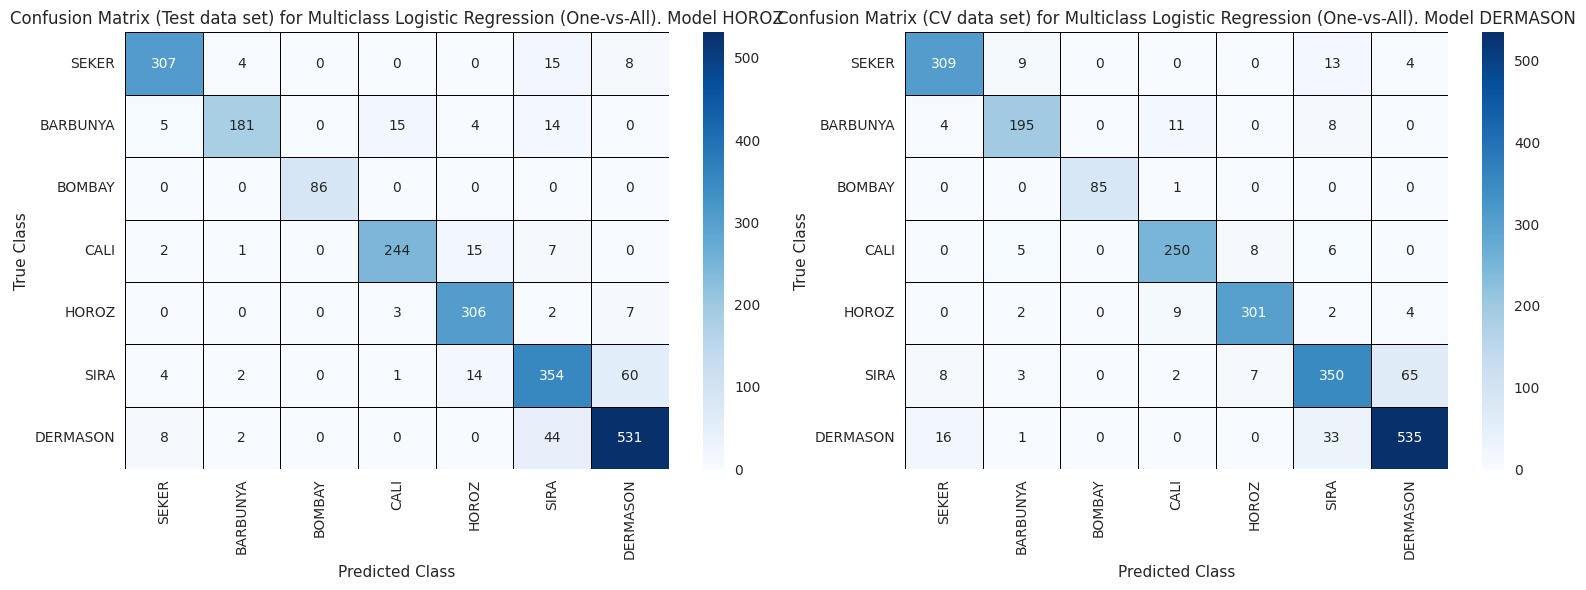

In [30]:
# Confusion Matrix
print("\nConfusion Matrix (Test Set - Multiclass OvA):")
conf_matrix_test = confusion_matrix(
    y_test_full, 
    y_test_pred_ova, 
    labels=label_encoder_full.transform(new_target_names)
)
conf_matrix_test_df = pd.DataFrame(
    conf_matrix_test,
    index=new_target_names, 
    columns=new_target_names
)

print("\nConfusion Matrix (CV Set - Multiclass OvA):")
conf_matrix_cv = confusion_matrix(
    y_cv_full, 
    y_cv_pred_ova, 
    labels=label_encoder_full.transform(new_target_names)
)
conf_matrix_cv_df = pd.DataFrame(
    conf_matrix_cv,
    index=new_target_names, 
    columns=new_target_names
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# test dataset 
sns.heatmap(
    conf_matrix_test_df, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    cbar=True,
    linewidths=.5, 
    linecolor='black'
)
axes[0].set_ylabel('True Class')
axes[0].set_xlabel('Predicted Class')
axes[0].set_title(f'Confusion Matrix (Test data set) for Multiclass Logistic Regression (One-vs-All). Model {class_name_test}')

# CV dataset
sns.heatmap(
    conf_matrix_cv_df, annot=True, fmt='d', cmap='Blues', ax=axes[1],
    cbar=True,
    linewidths=.5, 
    linecolor='black'
)
axes[1].set_ylabel('True Class')
axes[1].set_xlabel('Predicted Class')
axes[1].set_title(f'Confusion Matrix (CV data set) for Multiclass Logistic Regression (One-vs-All). Model {class_name_cv}')

plt.tight_layout()
plt.show()


Confusion Matrix (Test Set - Multiclass OvA):


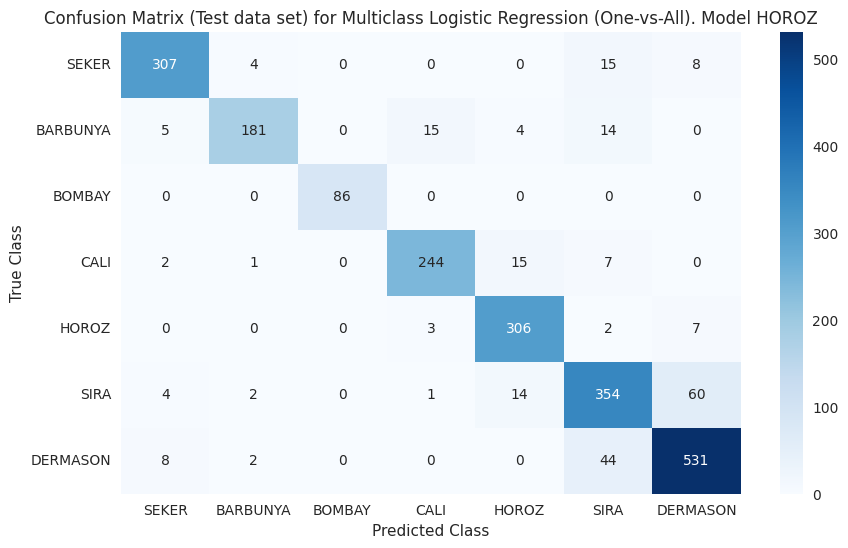

In [31]:
print("\nConfusion Matrix (Test Set - Multiclass OvA):")
conf_matrix_test = confusion_matrix(
    y_test_full, 
    y_test_pred_ova, 
    labels=label_encoder_full.transform(new_target_names)
)
conf_matrix_test_df = pd.DataFrame(
    conf_matrix_test,
    index=new_target_names, 
    columns=new_target_names
)

plt.figure(figsize=(10, 6))
# test dataset 
sns.heatmap(
    conf_matrix_test_df, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_desired_order, 
    yticklabels=labels_desired_order
)
plt.title(f'Confusion Matrix (Test data set) for Multiclass Logistic Regression (One-vs-All). Model {class_name_test}')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [32]:
print("\n--- Classification Test Report ---")
# This provides metrics for each of your 7 classes
report = classification_report(y_test_full, y_test_pred_ova, target_names=labels_desired_order, output_dict=True)
ut.classification_report_to_file(report, "lr_lab")

print(classification_report(y_test_full, y_test_pred_ova, target_names=labels_desired_order))


--- Classification Test Report ---
Metrics saved to 'classification_report/lr_lab.json'
              precision    recall  f1-score   support

       SEKER       0.95      0.83      0.89       219
    BARBUNYA       1.00      1.00      1.00        86
      BOMBAY       0.93      0.91      0.92       269
        CALI       0.88      0.91      0.89       585
       HOROZ       0.90      0.96      0.93       318
        SIRA       0.94      0.92      0.93       334
    DERMASON       0.81      0.81      0.81       435

    accuracy                           0.89      2246
   macro avg       0.92      0.91      0.91      2246
weighted avg       0.90      0.89      0.89      2246



## Softmax Regression (Multinomial Logistic Regression)

Instead of using One-vs-All strategy, we can train a single unified model using Softmax Regression. This approach:
- Uses a single model for all classes
- Ensures probabilities sum to 1
- Allows classes to compete for probability mass
- Often achieves better performance than One-vs-All


In [33]:
print("Training Softmax Regression (Multinomial Logistic Regression) with Regularization Tuning...")
print("=" * 70)

# Convert labels to one-hot encoding for softmax regression
onehot_encoder = OneHotEncoder(sparse_output=False)
Y_train_onehot = onehot_encoder.fit_transform(y_train_full.reshape(-1, 1))
Y_cv_onehot = onehot_encoder.transform(y_cv_full.reshape(-1, 1))
Y_test_onehot = onehot_encoder.transform(y_test_full.reshape(-1, 1))

# Initialize parameters for softmax regression
# all_w: (K, n) - one weight vector per class
# all_b: (K, 1) - one bias per class
initial_all_w = np.zeros((num_classes, X_train_scaled.shape[1]))
initial_all_b = np.zeros((num_classes, 1))

# Hyperparameters - Match Scikit_Learn notebook
alpha = 0.01  # Learning rate
num_iters = 10000  # Number of iterations (matching Scikit_Learn: 10000)

# Use the same lambda values as One-vs-All tuning
# lambda_values is already defined in Cell 42
print(f"Testing {len(lambda_values)} lambda values: {lambda_values}")
print(f"Number of iterations: {num_iters}")
print(f"Learning rate: {alpha}\n")

# Store results for each lambda value
softmax_lambda_results = {}

# Test each lambda value
for lambda_reg in lambda_values:
    print(f"\n{'='*70}")
    print(f"Testing lambda = {lambda_reg:.6f} (C = {1/lambda_reg:.3f})")
    print(f"{'='*70}")
    
    # Reinitialize parameters for each lambda
    all_w_lambda = np.zeros((num_classes, X_train_scaled.shape[1]))
    all_b_lambda = np.zeros((num_classes, 1))
    
    # Train the softmax model with this lambda
    all_w_lambda, all_b_lambda, J_history_lambda = lg.gradient_descent_softmax(
        X_train_scaled, Y_train_onehot, all_w_lambda, all_b_lambda, alpha, num_iters, lambda_reg
    )
    
    # Evaluate on CV set for this lambda
    y_cv_pred_lambda, _ = lg.predict_multiclass_softmax(
        X_cv_scaled, all_w_lambda, all_b_lambda
    )
    cv_accuracy_lambda = accuracy_score(y_cv_full, y_cv_pred_lambda)
    
    # Store results
    softmax_lambda_results[lambda_reg] = {
        'all_w': all_w_lambda,
        'all_b': all_b_lambda,
        'cv_accuracy': cv_accuracy_lambda,
        'cost_history': J_history_lambda
    }
    
    print(f"CV Accuracy for lambda={lambda_reg:.6f}: {cv_accuracy_lambda:.4f}")
    print(f"Final cost: {J_history_lambda[-1]:.4f}")

# Select best lambda based on CV accuracy
best_lambda_softmax = max(softmax_lambda_results.keys(), key=lambda l: softmax_lambda_results[l]['cv_accuracy'])
best_cv_accuracy_softmax = softmax_lambda_results[best_lambda_softmax]['cv_accuracy']

print(f"\n{'='*70}")
print(f"Best lambda for Softmax: {best_lambda_softmax:.6f} (C = {1/best_lambda_softmax:.3f})")
print(f"Best CV Accuracy: {best_cv_accuracy_softmax:.4f}")
print(f"{'='*70}\n")

# Use best lambda for final model
all_w_softmax = softmax_lambda_results[best_lambda_softmax]['all_w']
all_b_softmax = softmax_lambda_results[best_lambda_softmax]['all_b']
J_history_softmax = softmax_lambda_results[best_lambda_softmax]['cost_history']
lambda_reg_softmax = best_lambda_softmax  # Store best lambda for softmax

print(f"Using best lambda ({best_lambda_softmax:.6f}) for final Softmax model")


Training Softmax Regression (Multinomial Logistic Regression) with Regularization Tuning...
Testing 7 lambda values: [1.00000000e+03 3.16227766e+01 1.00000000e+00 3.16227766e-02
 1.00000000e-03 3.16227766e-05 1.00000000e-06]
Number of iterations: 10000
Learning rate: 0.01


Testing lambda = 1000.000000 (C = 0.001)
Iteration    0: Cost   1.9459   
Iteration 1000: Cost   0.9303   
Iteration 2000: Cost   0.9062   
Iteration 3000: Cost   0.8992   
Iteration 4000: Cost   0.8959   
Iteration 5000: Cost   0.8939   
Iteration 6000: Cost   0.8925   
Iteration 7000: Cost   0.8916   
Iteration 8000: Cost   0.8909   
Iteration 9000: Cost   0.8904   
Iteration 9999: Cost   0.8900   
CV Accuracy for lambda=1000.000000: 0.8963
Final cost: 0.8900

Testing lambda = 31.622777 (C = 0.032)
Iteration    0: Cost   1.9459   
Iteration 1000: Cost   0.5839   
Iteration 2000: Cost   0.4608   
Iteration 3000: Cost   0.4112   
Iteration 4000: Cost   0.3856   
Iteration 5000: Cost   0.3707   
Iteration 6000: Cost 

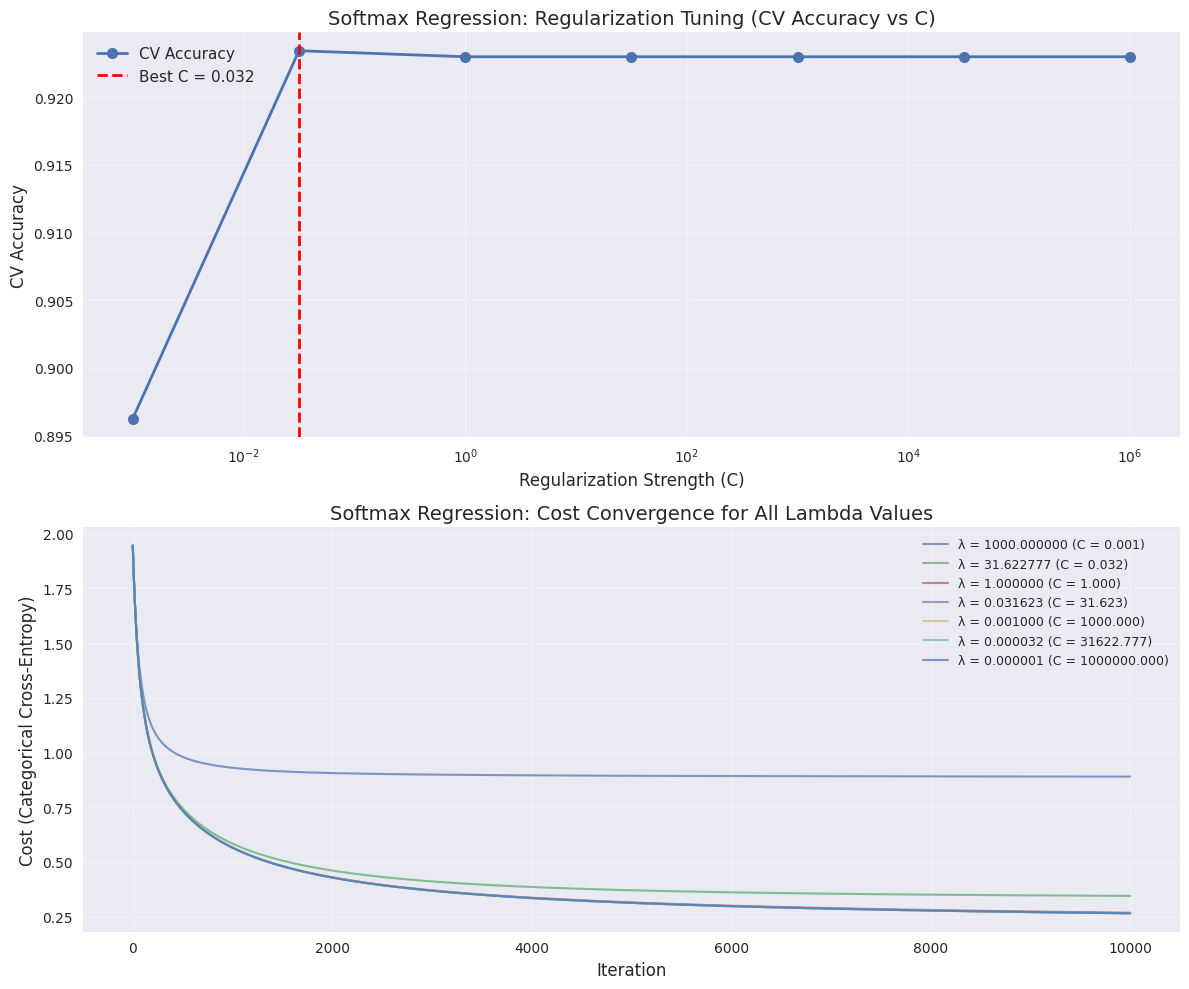


Softmax Regression Regularization Tuning Summary:
Lambda          C               CV Accuracy     Final Cost     
------------------------------------------------------------
0.000001        1000000.000     0.9230          0.2653         
0.000032        31622.777       0.9230          0.2653         
0.001000        1000.000        0.9230          0.2653         
0.031623        31.623          0.9230          0.2654         
1.000000        1.000           0.9230          0.2684         
31.622777       0.032           0.9234          0.3451         
1000.000000     0.001           0.8963          0.8900         


In [34]:
# Plot regularization tuning results for Softmax Regression
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: CV Accuracy vs Lambda (C)
lambda_vals = list(softmax_lambda_results.keys())
cv_accs = [softmax_lambda_results[l]['cv_accuracy'] for l in lambda_vals]
C_vals = [1/l for l in lambda_vals]

axes[0].plot(C_vals, cv_accs, marker='o', linewidth=2, markersize=8, label='CV Accuracy')
axes[0].axvline(x=1/best_lambda_softmax, color='r', linestyle='--', linewidth=2, 
                label=f'Best C = {1/best_lambda_softmax:.3f}')

axes[0].set_xlabel('Regularization Strength (C)', fontsize=12)
axes[0].set_ylabel('CV Accuracy', fontsize=12)
axes[0].set_title('Softmax Regression: Regularization Tuning (CV Accuracy vs C)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')  # Log scale to match Scikit_Learn visualization

# Bottom plot: Cost convergence for all lambdas
for lambda_reg, result in softmax_lambda_results.items():
    cost_history = result['cost_history']
    C_val = 1 / lambda_reg
    label = f'λ = {lambda_reg:.6f} (C = {C_val:.3f})'
    
    axes[1].plot(cost_history, label=label, linewidth=1.5, alpha=0.7)

axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cost (Categorical Cross-Entropy)', fontsize=12)
axes[1].set_title('Softmax Regression: Cost Convergence for All Lambda Values', fontsize=14)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print tuning summary
print(f"\nSoftmax Regression Regularization Tuning Summary:")
print(f"{'Lambda':<15} {'C':<15} {'CV Accuracy':<15} {'Final Cost':<15}")
print("-" * 60)
for l in sorted(lambda_vals):
    print(f"{l:<15.6f} {1/l:<15.3f} {softmax_lambda_results[l]['cv_accuracy']:<15.4f} {softmax_lambda_results[l]['cost_history'][-1]:<15.4f}")


In [35]:
# Evaluate Softmax Regression
y_train_pred_softmax, y_train_proba_softmax = lg.predict_multiclass_softmax(
    X_train_scaled, all_w_softmax, all_b_softmax
)
y_cv_pred_softmax, y_cv_proba_softmax = lg.predict_multiclass_softmax(
    X_cv_scaled, all_w_softmax, all_b_softmax
)
y_test_pred_softmax, y_test_proba_softmax = lg.predict_multiclass_softmax(
    X_test_scaled, all_w_softmax, all_b_softmax
)

# Calculate accuracies
train_acc_softmax = accuracy_score(y_train_full, y_train_pred_softmax)
cv_acc_softmax = accuracy_score(y_cv_full, y_cv_pred_softmax)
test_acc_softmax = accuracy_score(y_test_full, y_test_pred_softmax)

print("Softmax Regression Results:")
print(f"  Training Accuracy: {train_acc_softmax:.4f}")
print(f"  CV Accuracy: {cv_acc_softmax:.4f}")
print(f"  Test Accuracy: {test_acc_softmax:.4f}")

# Verify probabilities sum to 1
print(f"\nProbability sum check (should be 1.0 for all examples):")
print(f"  Train: min={np.min(np.sum(y_train_proba_softmax, axis=1)):.6f}, "
      f"max={np.max(np.sum(y_train_proba_softmax, axis=1)):.6f}")
print(f"  Test: min={np.min(np.sum(y_test_proba_softmax, axis=1)):.6f}, "
      f"max={np.max(np.sum(y_test_proba_softmax, axis=1)):.6f}")


Softmax Regression Results:
  Training Accuracy: 0.9208
  CV Accuracy: 0.9234
  Test Accuracy: 0.9078

Probability sum check (should be 1.0 for all examples):
  Train: min=1.000000, max=1.000000
  Test: min=1.000000, max=1.000000


In [36]:
# Compare One-vs-All vs Softmax Regression
print("=" * 70)
print("Comparison: One-vs-All vs Softmax Regression")
print("=" * 70)
print(f"{'Metric':<25} {'One-vs-All':<15} {'Softmax':<15} {'Difference':<15}")
print("-" * 70)
print(f"{'Training Accuracy':<25} {train_accuracy:<15.4f} {train_acc_softmax:<15.4f} {train_acc_softmax - train_accuracy:+.4f}")
print(f"{'CV Accuracy':<25} {cv_accuracy:<15.4f} {cv_acc_softmax:<15.4f} {cv_acc_softmax - cv_accuracy:+.4f}")
print(f"{'Test Accuracy':<25} {test_accuracy:<15.4f} {test_acc_softmax:<15.4f} {test_acc_softmax - test_accuracy:+.4f}")
print("=" * 70)


Comparison: One-vs-All vs Softmax Regression
Metric                    One-vs-All      Softmax         Difference     
----------------------------------------------------------------------
Training Accuracy         0.9033          0.9208          +0.0175
CV Accuracy               0.9016          0.9234          +0.0218
Test Accuracy             0.8945          0.9078          +0.0134


In [37]:
# Classification Report for Softmax Regression
print("\n--- Classification Test Report (Softmax Regression) ---")
report_softmax = classification_report(
    y_test_full, 
    y_test_pred_softmax, 
    labels=label_encoder_full.transform(labels_desired_order),
    target_names=labels_desired_order, 
    output_dict=True
)
ut.classification_report_to_file(report_softmax, "lr_lab_softmax")

print(classification_report(
    y_test_full, 
    y_test_pred_softmax, 
    labels=label_encoder_full.transform(labels_desired_order),
    target_names=labels_desired_order
))



--- Classification Test Report (Softmax Regression) ---
Metrics saved to 'classification_report/lr_lab_softmax.json'
              precision    recall  f1-score   support

       SEKER       0.95      0.93      0.94       334
    BARBUNYA       0.98      0.86      0.91       219
      BOMBAY       1.00      1.00      1.00        86
        CALI       0.94      0.94      0.94       269
       HOROZ       0.93      0.96      0.94       318
        SIRA       0.81      0.86      0.83       435
    DERMASON       0.90      0.90      0.90       585

    accuracy                           0.91      2246
   macro avg       0.93      0.92      0.92      2246
weighted avg       0.91      0.91      0.91      2246



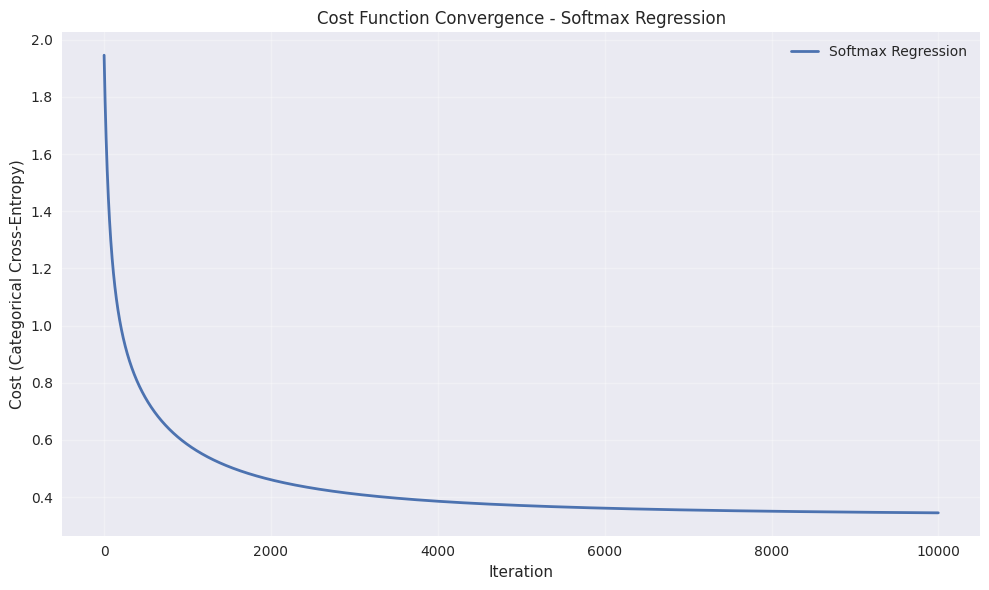

In [38]:
# Plot cost history for Softmax Regression
plt.figure(figsize=(10, 6))
plt.plot(J_history_softmax, linewidth=2, label='Softmax Regression')
plt.xlabel('Iteration')
plt.ylabel('Cost (Categorical Cross-Entropy)')
plt.title('Cost Function Convergence - Softmax Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


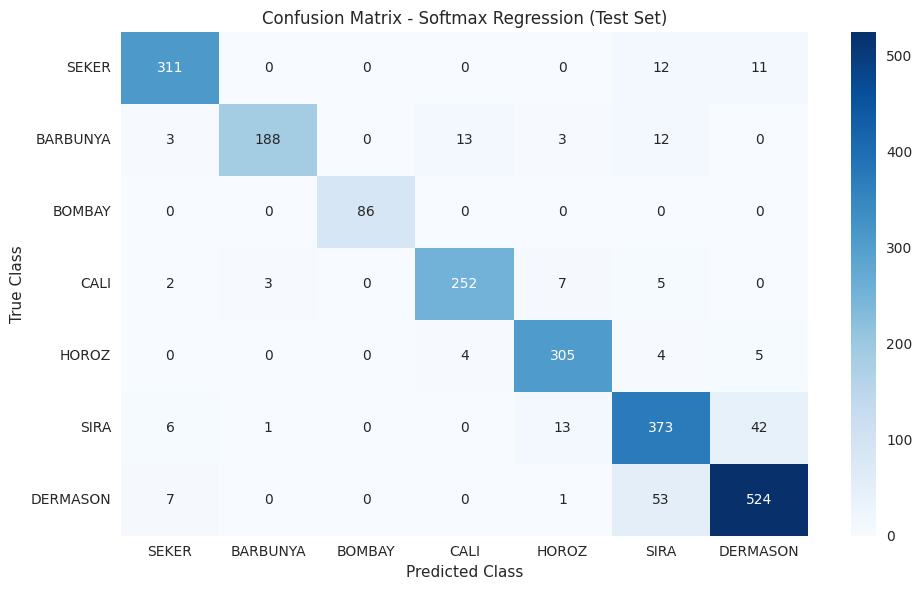

In [39]:
# Confusion Matrix for Softmax Regression
cm_softmax = confusion_matrix(
    y_test_full, 
    y_test_pred_softmax, 
    labels=label_encoder_full.transform(labels_desired_order)
)
cm_softmax_df = pd.DataFrame(
    cm_softmax,
    index=labels_desired_order, 
    columns=labels_desired_order
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    cm_softmax_df, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_desired_order, 
    yticklabels=labels_desired_order
)
plt.title('Confusion Matrix - Softmax Regression (Test Set)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()


In [40]:
print("\n--- Classification Test Report ---")
# This provides metrics for each of your 7 classes
report = classification_report(y_test_full, y_test_pred_softmax, target_names=labels_desired_order, output_dict=True)
ut.classification_report_to_file(report, "lr_lab_softmax")

print(classification_report(y_test_full, y_test_pred_softmax, target_names=labels_desired_order))


--- Classification Test Report ---
Metrics saved to 'classification_report/lr_lab_softmax.json'
              precision    recall  f1-score   support

       SEKER       0.98      0.86      0.91       219
    BARBUNYA       1.00      1.00      1.00        86
      BOMBAY       0.94      0.94      0.94       269
        CALI       0.90      0.90      0.90       585
       HOROZ       0.93      0.96      0.94       318
        SIRA       0.95      0.93      0.94       334
    DERMASON       0.81      0.86      0.83       435

    accuracy                           0.91      2246
   macro avg       0.93      0.92      0.92      2246
weighted avg       0.91      0.91      0.91      2246

